# 3. 모평균의 추정과 신뢰도

표본평균 $\bar{x}$ 주변의 **신뢰구간**:
$$\bar{x} \pm z_{\alpha/2} \cdot \dfrac{\sigma}{\sqrt{n}}$$

95% 신뢰구간: $z_{0.025} \approx 1.96$

## 1. 신뢰구간 계산

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

np.random.seed(1)
mu_true, sigma = 100, 15
n = 25
sample = np.random.normal(mu_true, sigma, n)
x_bar = sample.mean()
se = sigma / np.sqrt(n)
z = norm.ppf(0.975)  # 95% CI
ci_low = x_bar - z * se
ci_high = x_bar + z * se

print(f"표본평균 x̄ = {x_bar:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"모평균 μ = {mu_true} (참값)")

표본평균 x̄ = 99.81
95% CI: [93.93, 105.69]
모평균 μ = 100 (참값)


**norm.ppf(0.975)**: <br>
=> 95% 양측 신뢰구간의 z값 ≈ 1.96

**신뢰구간**: <br>
=> 반복 추출 시 95%가 μ를 포함

## 2. 신뢰구간 시각화

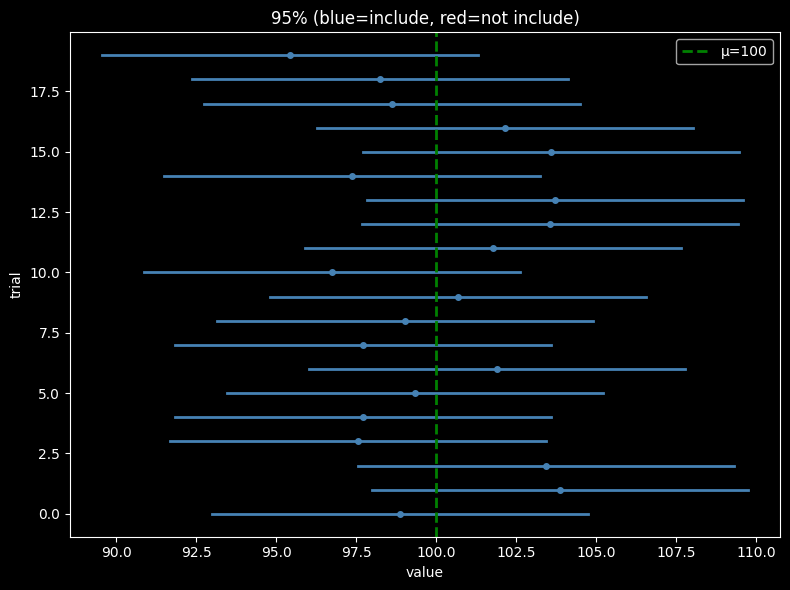

In [3]:
n_trials = 20
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(n_trials):
    s = np.random.normal(mu_true, sigma, n)
    m = s.mean()
    lo, hi = m - z * se, m + z * se
    color = 'steelblue' if lo <= mu_true <= hi else 'red'
    ax.plot([lo, hi], [i, i], color=color, lw=2)
    ax.plot(m, i, 'o', color=color, ms=4)
ax.axvline(mu_true, color='green', ls='--', lw=2, label=f'μ={mu_true}')
ax.set_xlabel('value')
ax.set_ylabel('trial')
ax.legend()
ax.set_title('95% (blue=include, red=not include)')
plt.tight_layout()
plt.show()